# Space Mission Analytics — Exploratory Data Analysis
4,630 missions from 1957 to present. Let's find the story in the data.

In [1]:
import pandas as pd
import plotly.express as px
import plotly.graph_objects as go
from sqlalchemy import create_engine
from dotenv import load_dotenv
import os

load_dotenv('../.env')
engine = create_engine(os.getenv('DB_URL'))
df = pd.read_sql('SELECT * FROM raw_space_missions', engine)
print(df.shape)
df.head()

(4630, 12)


,company,location,date,time,rocket,mission,rocketstatus,price,missionstatus,year,decade,country
0,RVSN USSR,"Site 1/5, Baikonur Cosmodrome, Kazakhstan",1957-10-04,19:28:00,Sputnik 8K71PS,Sputnik-1,Retired,NaN,Success,1957,1950,Kazakhstan
1,RVSN USSR,"Site 1/5, Baikonur Cosmodrome, Kazakhstan",1957-11-03,02:30:00,Sputnik 8K71PS,Sputnik-2,Retired,NaN,Success,1957,1950,Kazakhstan
2,US Navy,"LC-18A, Cape Canaveral AFS, Florida, USA",1957-12-06,16:44:00,Vanguard,Vanguard TV3,Retired,NaN,Failure,1957,1950,USA
3,AMBA,"LC-26A, Cape Canaveral AFS, Florida, USA",1958-02-01,03:48:00,Juno I,Explorer 1,Retired,NaN,Success,1958,1950,USA
4,US Navy,"LC-18A, Cape Canaveral AFS, Florida, USA",1958-02-05,07:33:00,Vanguard,Vanguard TV3BU,Retired,NaN,Failure,1958,1950,USA


## 1. Data Quality Check

In [2]:
print('Nulls per column:')
print(df.isnull().sum())
print(f'\nDate range: {df["date"].min()} → {df["date"].max()}')
print(f'Unique companies: {df["company"].nunique()}')
print(f'Unique rockets: {df["rocket"].nunique()}')
print(f'Mission statuses: {df["missionstatus"].unique()}')

Nulls per column:
company             0
location            0
date                0
time              127
rocket              0
mission             0
rocketstatus        0
price            3365
missionstatus       0
year                0
decade              0
country             0
dtype: int64

Date range: 1957-10-04 00:00:00 → 2022-07-29 00:00:00
Unique companies: 62
Unique rockets: 370
Mission statuses: <StringArray>
['Success', 'Failure', 'Partial Failure', 'Prelaunch Failure']
Length: 4, dtype: str


## 2. Mission Success Rate Over Time

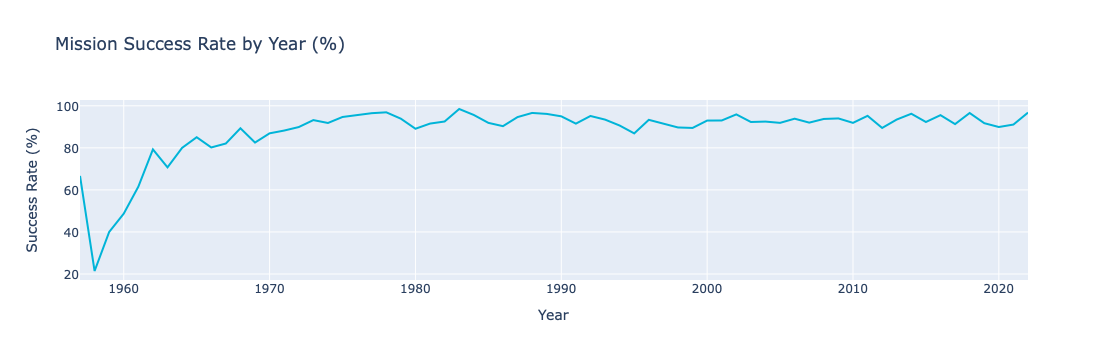

In [3]:
success = df.groupby('year').apply(
    lambda x: (x['missionstatus'] == 'Success').sum() / len(x) * 100
).reset_index()
success.columns = ['year', 'success_rate']

fig = px.line(success, x='year', y='success_rate',
              title='Mission Success Rate by Year (%)',
              labels={'success_rate': 'Success Rate (%)', 'year': 'Year'})
fig.update_traces(line_color='#00b4d8')
fig.show()

## 3. Top 10 Companies by Total Launches

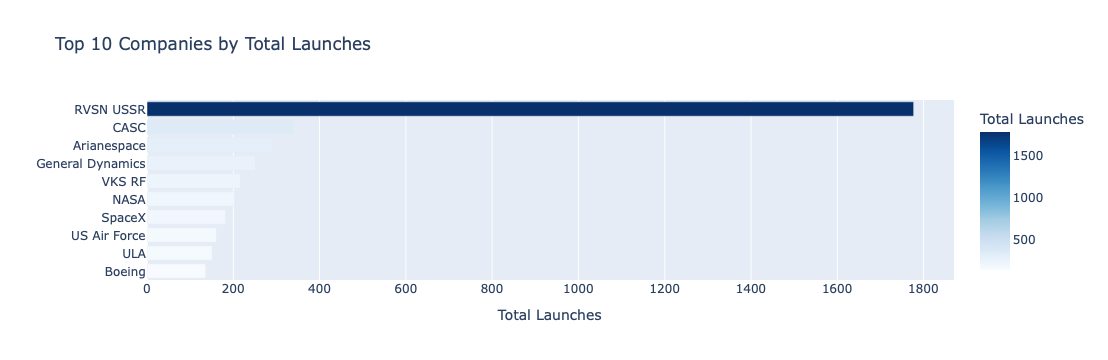

In [4]:
top_companies = df['company'].value_counts().head(10).reset_index()
top_companies.columns = ['company', 'launches']

fig = px.bar(top_companies, x='launches', y='company', orientation='h',
             title='Top 10 Companies by Total Launches',
             labels={'launches': 'Total Launches', 'company': ''},
             color='launches', color_continuous_scale='Blues')
fig.update_layout(yaxis={'categoryorder': 'total ascending'})
fig.show()

## 4. Launches Per Year — Space Race vs Modern Era

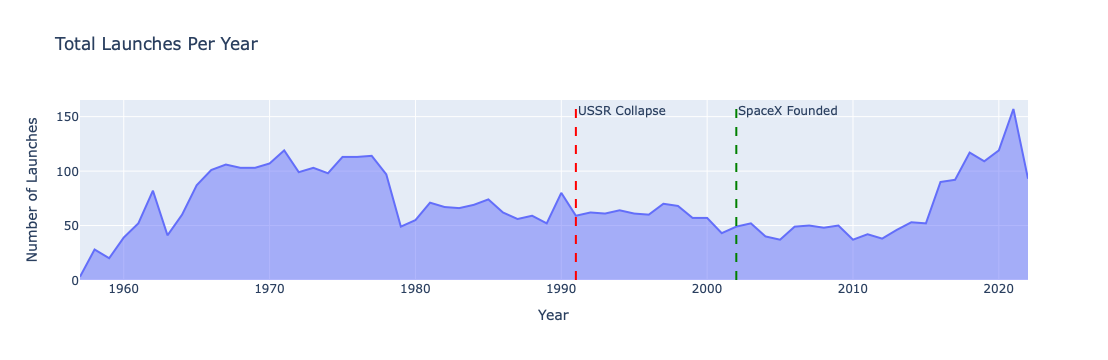

In [5]:
launches_per_year = df.groupby('year').size().reset_index(name='launches')

fig = px.area(launches_per_year, x='year', y='launches',
              title='Total Launches Per Year',
              labels={'launches': 'Number of Launches', 'year': 'Year'})
fig.add_vline(x=1991, line_dash='dash', line_color='red',
              annotation_text='USSR Collapse', annotation_position='top right')
fig.add_vline(x=2002, line_dash='dash', line_color='green',
              annotation_text='SpaceX Founded', annotation_position='top right')
fig.show()

## 5. Government vs Commercial Launches Over Time

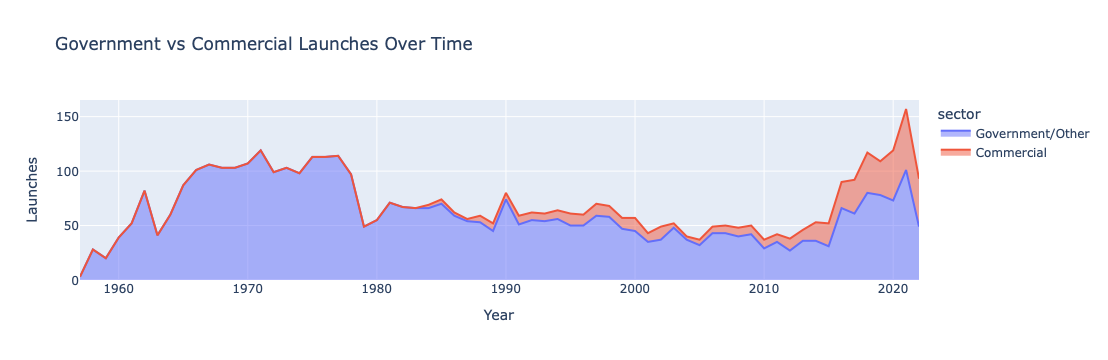

In [6]:
commercial = ['SpaceX', 'Rocket Lab', 'Blue Origin', 'Virgin Orbit', 'Arianespace']
df['sector'] = df['company'].apply(lambda x: 'Commercial' if x in commercial else 'Government/Other')

sector_year = df.groupby(['year', 'sector']).size().reset_index(name='launches')

fig = px.area(sector_year, x='year', y='launches', color='sector',
              title='Government vs Commercial Launches Over Time',
              labels={'launches': 'Launches', 'year': 'Year'})
fig.show()

## 6. Most Reliable Rockets (min 10 launches)

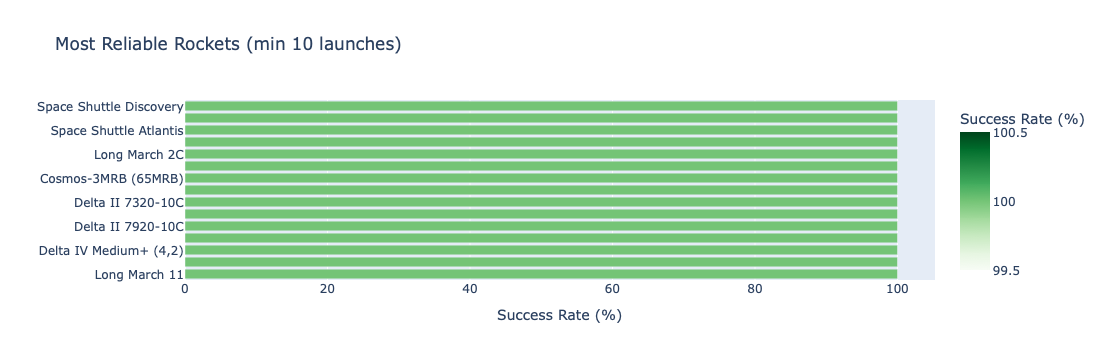

In [7]:
rocket_stats = df.groupby('rocket').agg(
    total=('missionstatus', 'count'),
    success=('missionstatus', lambda x: (x == 'Success').sum())
).reset_index()
rocket_stats['success_rate'] = (rocket_stats['success'] / rocket_stats['total'] * 100).round(1)
rocket_stats = rocket_stats[rocket_stats['total'] >= 10].sort_values('success_rate', ascending=False).head(15)

fig = px.bar(rocket_stats, x='success_rate', y='rocket', orientation='h',
             title='Most Reliable Rockets (min 10 launches)',
             labels={'success_rate': 'Success Rate (%)', 'rocket': ''},
             color='success_rate', color_continuous_scale='Greens',
             hover_data=['total'])
fig.update_layout(yaxis={'categoryorder': 'total ascending'})
fig.show()

## 7. Launch Countries — Who Dominates?

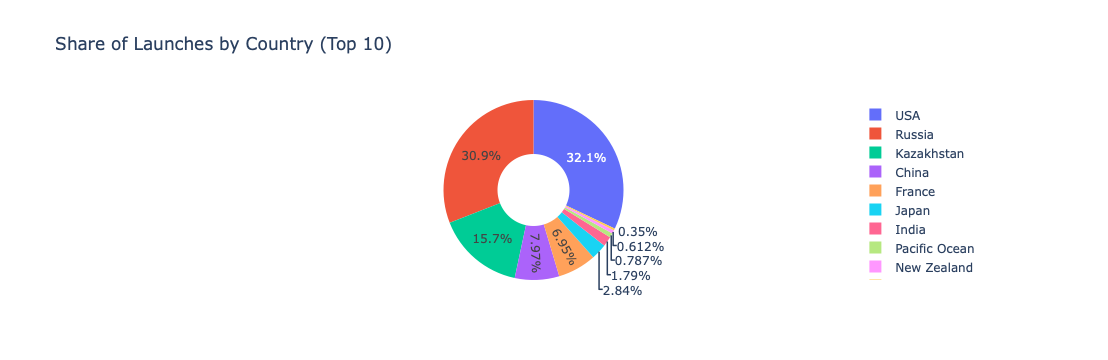

In [8]:
country_counts = df['country'].value_counts().head(10).reset_index()
country_counts.columns = ['country', 'launches']

fig = px.pie(country_counts, values='launches', names='country',
             title='Share of Launches by Country (Top 10)',
             hole=0.4)
fig.show()

## 8. Mission Cost Distribution (where available)

Missions with price data: 1265 / 4630


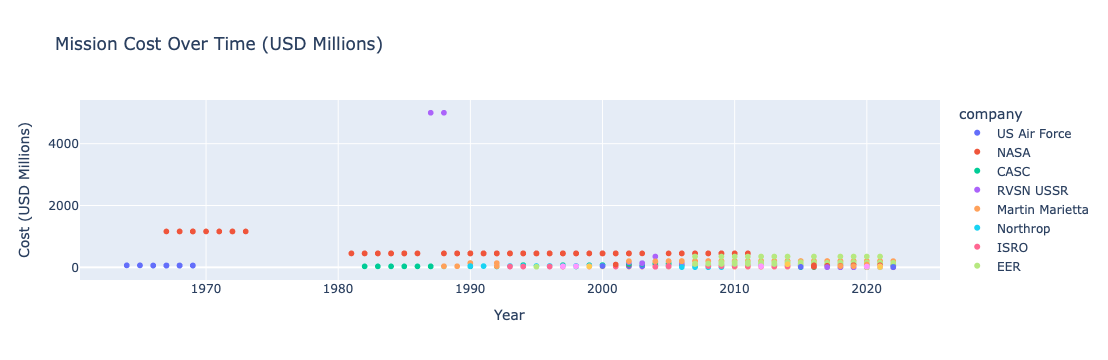

In [9]:
priced = df.dropna(subset=['price'])
print(f'Missions with price data: {len(priced)} / {len(df)}')

fig = px.scatter(priced, x='year', y='price', color='company',
                 title='Mission Cost Over Time (USD Millions)',
                 labels={'price': 'Cost (USD Millions)', 'year': 'Year'},
                 hover_data=['mission', 'rocket'])
fig.show()

## 9. Key Findings Summary

In [10]:
total = len(df)
success_rate = (df['missionstatus'] == 'Success').mean() * 100
top_company = df['company'].value_counts().index[0]
busiest_year = launches_per_year.loc[launches_per_year['launches'].idxmax(), 'year']

print(f'Total missions analyzed : {total:,}')
print(f'Overall success rate     : {success_rate:.1f}%')
print(f'Most active company      : {top_company}')
print(f'Busiest launch year      : {busiest_year}')
print(f'Missions with cost data  : {len(priced)} ({len(priced)/total*100:.1f}%)')

Total missions analyzed : 4,630
Overall success rate     : 89.9%
Most active company      : RVSN USSR
Busiest launch year      : 2021
Missions with cost data  : 1265 (27.3%)
